# Sudoku Digit Classification and Solving with PyTorch
## Complete Computer Vision Pipeline

This notebook implements a complete pipeline for:
1. Data preparation and visualization
2. CNN model architecture design
3. Model training with metrics visualization
4. Comprehensive model evaluation
5. Image processing and grid detection
6. End-to-end sudoku solving

## Section 1: Setup & Environment
Mount Google Drive, install packages, and verify GPU availability

In [1]:
# Install required packages
#!pip install torch torchvision -q
#!pip install opencv-python scikit-learn matplotlib seaborn numpy pandas -q
!pip install imutils -q

In [2]:
# Import all necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms

import cv2
import imutils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

import os
import sys
import glob
import copy
import math
import warnings
from datetime import datetime
from pathlib import Path

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [3]:
# Verify GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"PyTorch Version: {torch.__version__}")

Device: cuda
GPU Name: Tesla T4
GPU Memory: 15.64 GB
PyTorch Version: 2.10.0+cu128


In [4]:
# Set working directory and paths
base_path = '/kaggle/working/cv-sudoku'
data_path = '/kaggle/input/datasets/mohammadsharifbeigy/'
model_save_dir = os.path.join(base_path, 'models')
output_dir = os.path.join(base_path, 'notebook_outputs')

Path(model_save_dir).mkdir(parents=True, exist_ok=True)
Path(output_dir).mkdir(parents=True, exist_ok=True)

print(f"Base path: {base_path}")
print(f"Data path: {data_path}")
print(f"Model save directory: {model_save_dir}")

Base path: /kaggle/working/cv-sudoku
Data path: /kaggle/input/datasets/mohammadsharifbeigy/
Model save directory: /kaggle/working/cv-sudoku/models


## Section 2: Data Preparation & Visualization

In [5]:
def load_mnist_images():
    """
    Load MNIST dataset, remove zeros (invalid sudoku entries), and prepare
    train/validation/test splits with normalization.
    """
    mnist_save_path = '/kaggle/working/MNIST-torch'
    
    os.makedirs(mnist_save_path, exist_ok=True)

    mnist_train = datasets.MNIST(root=mnist_save_path, train=True, download=True)
    mnist_test = datasets.MNIST(root=mnist_save_path, train=False, download=True)

    x_train = mnist_train.data.numpy().astype('float32')
    y_train = mnist_train.targets.numpy()
    x_test = mnist_test.data.numpy().astype('float32')
    y_test = mnist_test.targets.numpy()

    # Remove zero images
    non_zero_train_indices = np.where(y_train != 0)[0]
    non_zero_test_indices = np.where(y_test != 0)[0]

    x_train = x_train[non_zero_train_indices]
    y_train = y_train[non_zero_train_indices]
    x_test = x_test[non_zero_test_indices]
    y_test = y_test[non_zero_test_indices]

    # Create validation set
    x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,
                                                       train_size=0.85,
                                                       random_state=2023)

    # Normalize
    x_train = x_train / 255.0
    x_val = x_val / 255.0
    x_test = x_test / 255.0

    # Add channel dimension
    x_train = np.expand_dims(x_train, 1)
    x_val = np.expand_dims(x_val, 1)
    x_test = np.expand_dims(x_test, 1)

    # Convert to tensors
    x_train = torch.from_numpy(x_train)
    x_val = torch.from_numpy(x_val)
    x_test = torch.from_numpy(x_test)
    y_train = torch.from_numpy(y_train - 1).long()
    y_val = torch.from_numpy(y_val - 1).long()
    y_test = torch.from_numpy(y_test - 1).long()

    return x_train, x_val, x_test, y_train, y_val, y_test

print("Loading MNIST dataset...")
x_train_mnist, x_val_mnist, x_test_mnist, y_train_mnist, y_val_mnist, y_test_mnist = load_mnist_images()
print(f"MNIST - Train: {x_train_mnist.shape}, Val: {x_val_mnist.shape}, Test: {x_test_mnist.shape}")

Loading MNIST dataset...


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 347kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.46MB/s]


MNIST - Train: torch.Size([45965, 1, 28, 28]), Val: torch.Size([8112, 1, 28, 28]), Test: torch.Size([9020, 1, 28, 28])


In [6]:
def get_font_image_dict(data_path, excluded_names=None):
    """
    Load font digit images and resize to 28x28.
    """
    base_digit_path = os.path.join(data_path, 'digit-images', 'digit_images')
    
    folder_names = sorted(glob.glob(os.path.join(base_digit_path, '*')))
    
    digit_image_filepaths = [sorted(glob.glob(os.path.join(folder, '*.png'))) for folder in folder_names]

    if len(digit_image_filepaths) == 0:
        raise ValueError(f"No folders found in path: {base_digit_path}. Please check the directory structure.")

    if excluded_names:
        inclusion_list_indices = list(np.where([not any(elem in fpath for elem in excluded_names)
                                                for fpath in digit_image_filepaths[0]])[0])
        digit_image_filepaths = [[fpath_list[i] for i in inclusion_list_indices]
                                 for fpath_list in digit_image_filepaths]

    img_dict = {i: None for i in range(1, 10)}
    for k in img_dict:
        img_dict[k] = [cv2.imread(fpath) for fpath in digit_image_filepaths[k-1]]

    for k, v in img_dict.items():
        gray = [cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY) for arr in v]
        img_dict[k] = [cv2.resize(arr, (28, 28), interpolation=cv2.INTER_AREA) for arr in gray]
        img_dict[k] = np.transpose(np.expand_dims(img_dict[k], -1), (0, 3, 1, 2))

    return img_dict

print("Loading font digit images...")
img_dict = get_font_image_dict(data_path, excluded_names=None)
print(f"Font images loaded: {len(img_dict)} classes")

Loading font digit images...
Font images loaded: 9 classes


In [7]:
def load_font_image_arrays(image_dict):
    """
    Process font images and split into train/val/test.
    """
    x = np.concatenate([v for v in image_dict.values()], axis=0)
    
    # Use np.concatenate to safely handle classes with different numbers of images
    y = np.concatenate([np.repeat(k, len(image_dict[k])) for k in image_dict])
    
    # Pass the shape tuple directly without the 'newshape' keyword
    y = np.reshape(y, (-1, 1)) - 1

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15,
                                                        shuffle=True, random_state=0)
    x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,
                                                      test_size=0.18, shuffle=True,
                                                      random_state=33)

    # Invert and normalize
    x_train = np.array(list(map(cv2.bitwise_not, x_train.squeeze(1))))
    x_val = np.array(list(map(cv2.bitwise_not, x_val.squeeze(1))))
    x_test = np.array(list(map(cv2.bitwise_not, x_test.squeeze(1))))

    x_train = np.expand_dims(x_train, 1)
    x_val = np.expand_dims(x_val, 1)
    x_test = np.expand_dims(x_test, 1)

    x_train = torch.from_numpy(x_train.astype('float32') / 255)
    x_val = torch.from_numpy(x_val.astype('float32') / 255)
    x_test = torch.from_numpy(x_test.astype('float32') / 255)
    
    y_train = torch.from_numpy(y_train.flatten()).long()
    y_val = torch.from_numpy(y_val.flatten()).long()
    y_test = torch.from_numpy(y_test.flatten()).long()

    return x_train, x_val, x_test, y_train, y_val, y_test

print("Processing font images...")
x_train_fonts, x_val_fonts, x_test_fonts, y_train_fonts, y_val_fonts, y_test_fonts = load_font_image_arrays(img_dict)
print(f"Fonts - Train: {x_train_fonts.shape}, Val: {x_val_fonts.shape}, Test: {x_test_fonts.shape}")

Processing font images...
Fonts - Train: torch.Size([6373, 1, 28, 28]), Val: torch.Size([1399, 1, 28, 28]), Test: torch.Size([1372, 1, 28, 28])


In [8]:
# Combine both datasets
x_train = torch.cat((x_train_fonts, x_train_mnist), dim=0)
x_val = torch.cat((x_val_fonts, x_val_mnist), dim=0)
x_test = torch.cat((x_test_fonts, x_test_mnist), dim=0)
y_train = torch.cat((y_train_fonts, y_train_mnist), dim=0)
y_val = torch.cat((y_val_fonts, y_val_mnist), dim=0)
y_test = torch.cat((y_test_fonts, y_test_mnist), dim=0)

print(f"\nCombined Dataset:")
print(f"Training: {x_train.shape}, Labels: {y_train.shape}")
print(f"Validation: {x_val.shape}, Labels: {y_val.shape}")
print(f"Testing: {x_test.shape}, Labels: {y_test.shape}")
print(f"Total samples: {x_train.shape[0] + x_val.shape[0] + x_test.shape[0]}")


Combined Dataset:
Training: torch.Size([52338, 1, 28, 28]), Labels: torch.Size([52338])
Validation: torch.Size([9511, 1, 28, 28]), Labels: torch.Size([9511])
Testing: torch.Size([10392, 1, 28, 28]), Labels: torch.Size([10392])
Total samples: 72241


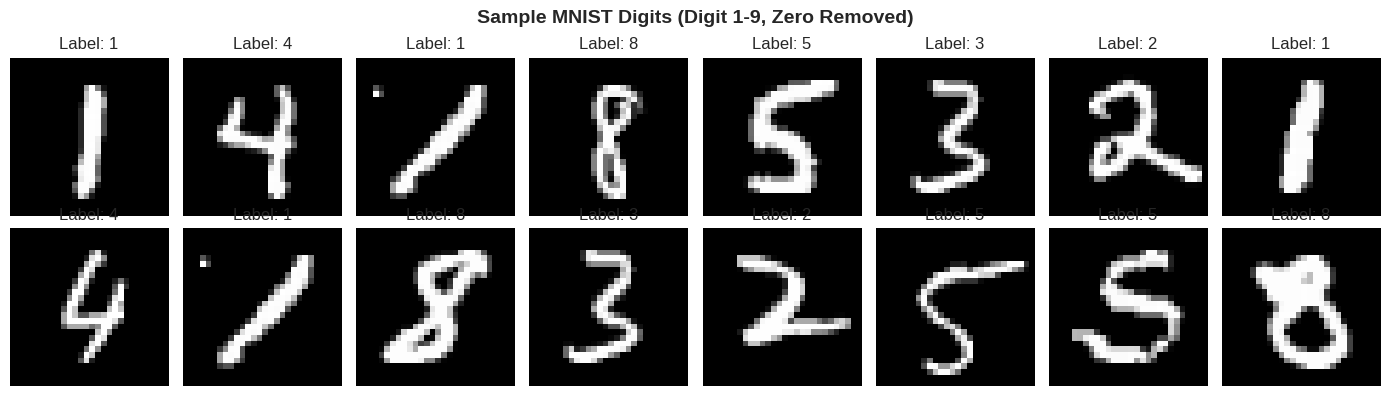

Saved: mnist_samples.png


In [9]:
# Visualization: Sample MNIST digits (before/after filtering)
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Sample MNIST Digits (Digit 1-9, Zero Removed)', fontsize=14, fontweight='bold')

for i in range(8):
    # Training samples
    idx = i * 100
    axes[0, i].imshow(x_train_mnist[idx, 0], cmap='gray')
    axes[0, i].set_title(f'Label: {y_train_mnist[idx] + 1}')
    axes[0, i].axis('off')

    # Different samples
    idx = i * 150 + 50
    axes[1, i].imshow(x_train_mnist[idx, 0], cmap='gray')
    axes[1, i].set_title(f'Label: {y_train_mnist[idx] + 1}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'mnist_samples.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mnist_samples.png")

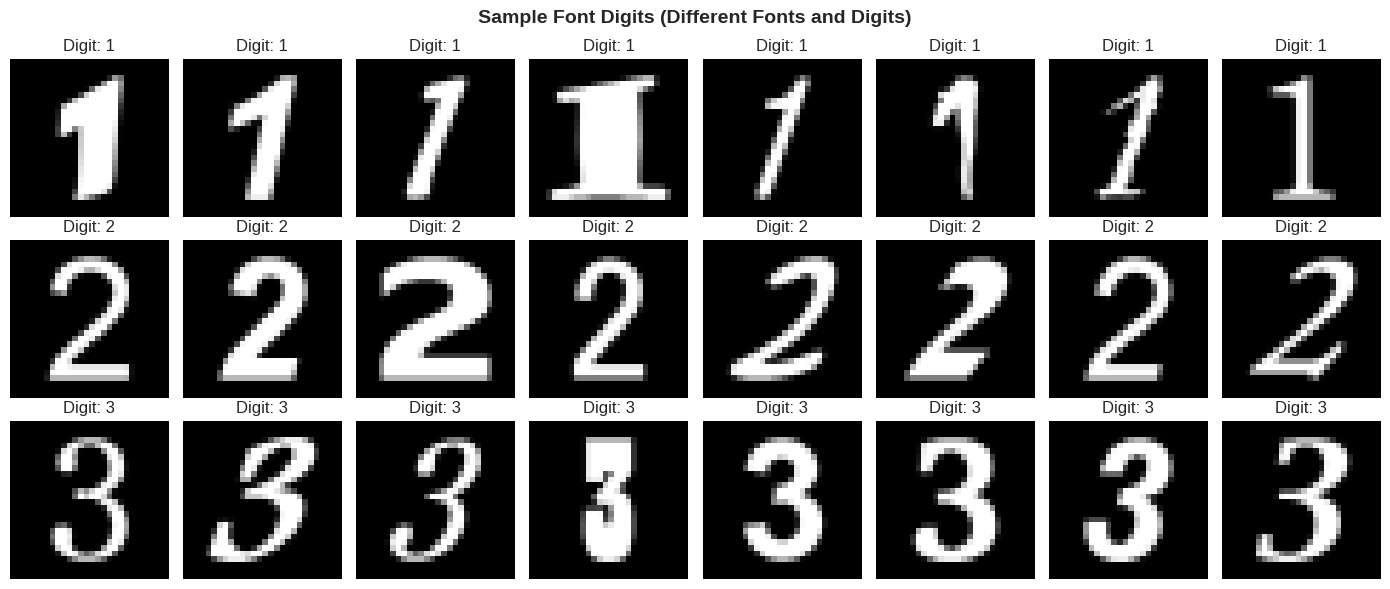

Saved: font_samples.png


In [10]:
# Visualization: Sample font digits
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
fig.suptitle('Sample Font Digits (Different Fonts and Digits)', fontsize=14, fontweight='bold')

for digit in range(3):
    for i in range(8):
        # Get samples from font dataset
        mask = y_train_fonts == digit
        indices = np.where(mask.numpy())[0]
        if len(indices) > i * 20:
            idx = indices[i * 20]
            axes[digit, i].imshow(x_train_fonts[idx, 0], cmap='gray')
            axes[digit, i].set_title(f'Digit: {digit + 1}')
            axes[digit, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'font_samples.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: font_samples.png")

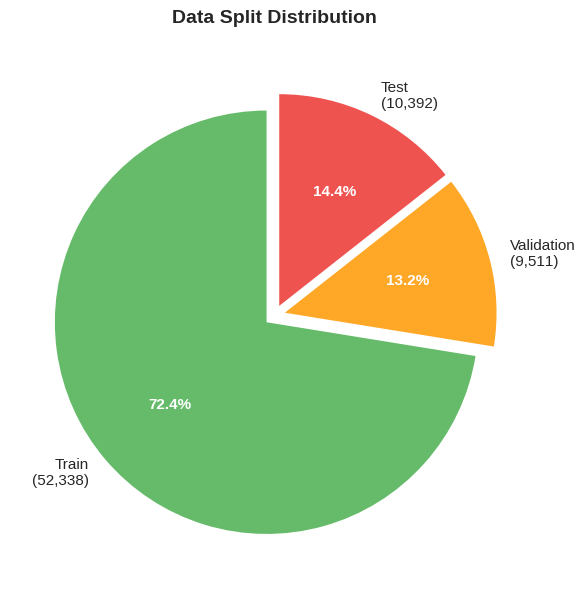

Saved: data_distribution.png


In [11]:
# Visualization: Data distribution pie chart
sizes = [x_train.shape[0], x_val.shape[0], x_test.shape[0]]
labels = [f'Train\n({sizes[0]:,})', f'Validation\n({sizes[1]:,})', f'Test\n({sizes[2]:,})']
colors = ['#66bb6a', '#ffa726', '#ef5350']
explode = (0.05, 0.05, 0.05)

fig, ax = plt.subplots(figsize=(10, 6))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
                                    explode=explode, startangle=90, textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Data Split Distribution', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'data_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data_distribution.png")

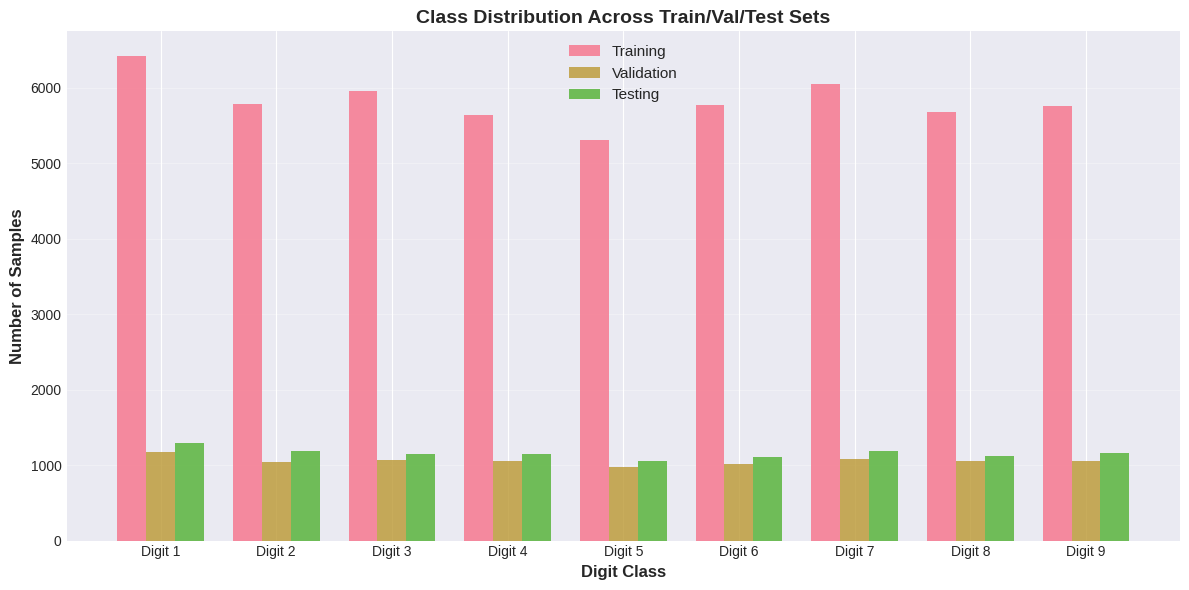

Saved: class_distribution.png


In [12]:
# Visualization: Class distribution histogram
train_counts = np.bincount(y_train.numpy())
val_counts = np.bincount(y_val.numpy())
test_counts = np.bincount(y_test.numpy())

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(1, 10)
width = 0.25

ax.bar(x - width, train_counts, width, label='Training', alpha=0.8)
ax.bar(x, val_counts, width, label='Validation', alpha=0.8)
ax.bar(x + width, test_counts, width, label='Testing', alpha=0.8)

ax.set_xlabel('Digit Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution Across Train/Val/Test Sets', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Digit {i}' for i in range(1, 10)])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

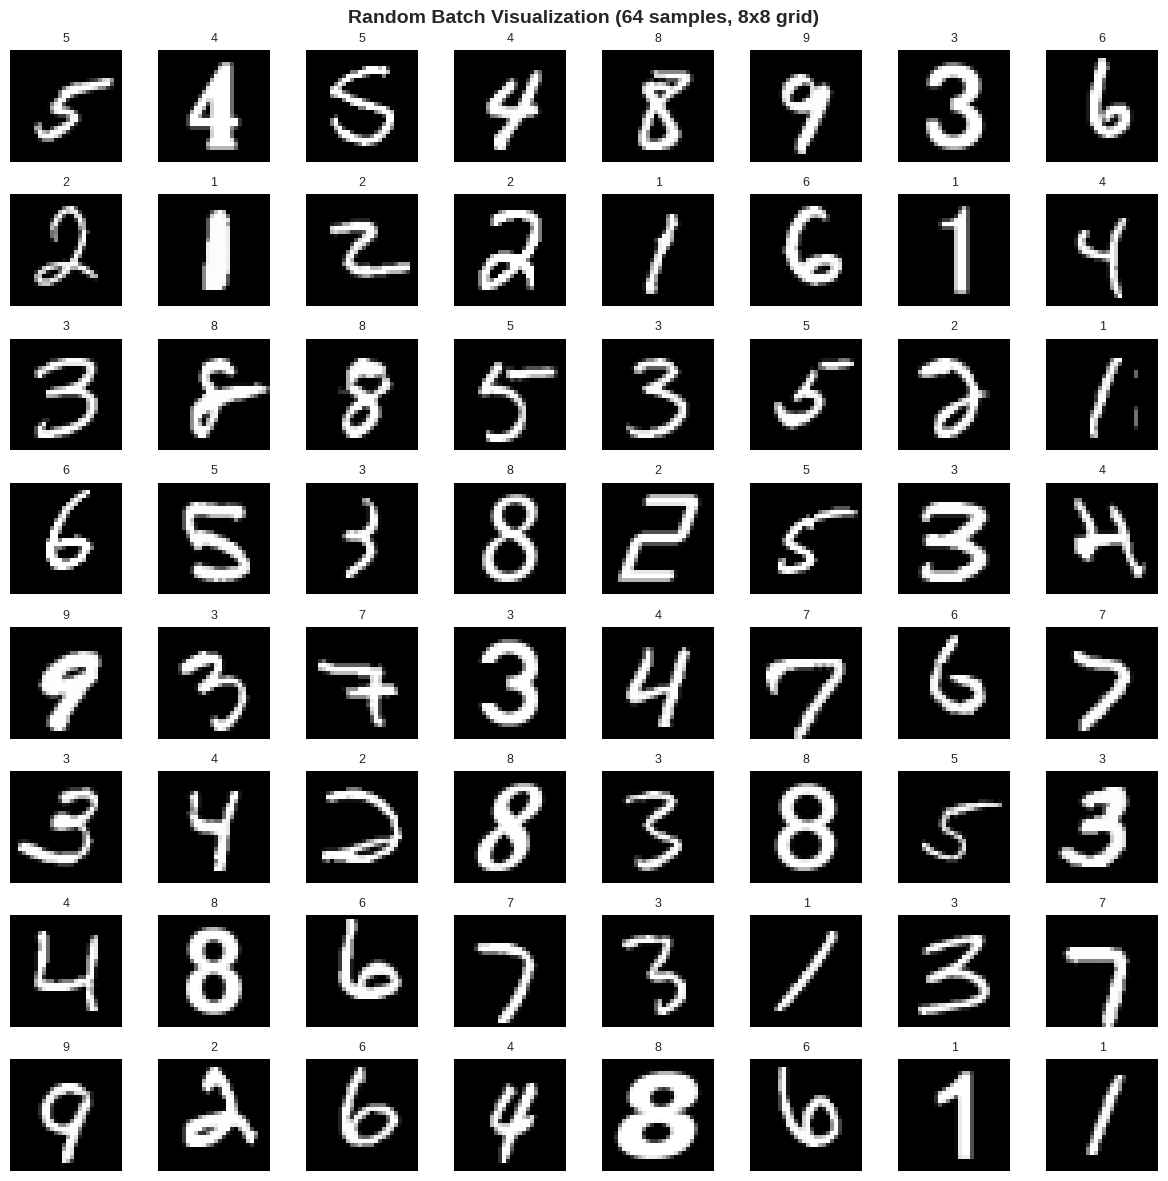

Saved: batch_visualization.png


In [13]:
# Visualization: Random batch visualization (8x8 grid)
batch_size = 64
random_indices = np.random.choice(x_train.shape[0], batch_size, replace=False)
batch_images = x_train[random_indices]
batch_labels = y_train[random_indices]

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
fig.suptitle('Random Batch Visualization (64 samples, 8x8 grid)', fontsize=14, fontweight='bold')

for idx, (img, label) in enumerate(zip(batch_images, batch_labels)):
    ax = axes[idx // 8, idx % 8]
    ax.imshow(img[0], cmap='gray')
    ax.set_title(f'{label.item() + 1}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'batch_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: batch_visualization.png")

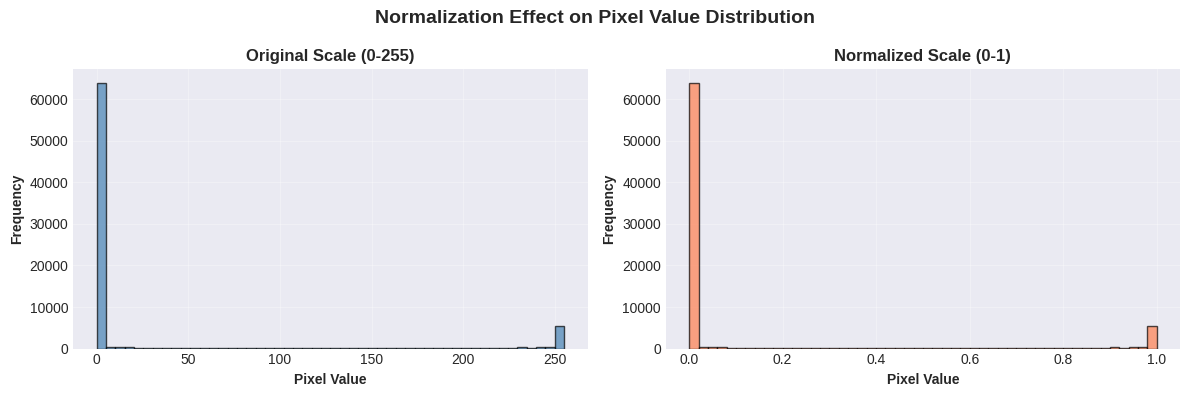

Saved: normalization_effect.png


In [30]:
# Visualization: Normalization effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Normalization Effect on Pixel Value Distribution', fontsize=14, fontweight='bold')

# Original (0-255 scale)
original_pixels = (x_train_mnist[:100, 0].numpy() * 255).flatten()
axes[0].hist(original_pixels, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Pixel Value', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Original Scale (0-255)', fontweight='bold')
axes[0].grid(alpha=0.3)

# Normalized (0-1 scale)
normalized_pixels = x_train_mnist[:100, 0].numpy().flatten()
axes[1].hist(normalized_pixels, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Pixel Value', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Normalized Scale (0-1)', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'normalization_effect.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: normalization_effect.png")

## Section 3: Model Architecture & Design

In [14]:
class DigitCNN(nn.Module):
    """
    CNN model for digit classification (1-9).
    """
    def __init__(self, num_classes=9):
        super(DigitCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(p=0.5)

        # After two max pooling operations: 28 -> 14 -> 7
        # So input to fc layer is 64 * 7 * 7 = 3136
        self.fc = nn.Linear(64 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc(x)

        return x

# Create model instance
model = DigitCNN(num_classes=9)
model = model.to(device)
print("Model created and moved to device")

Model created and moved to device


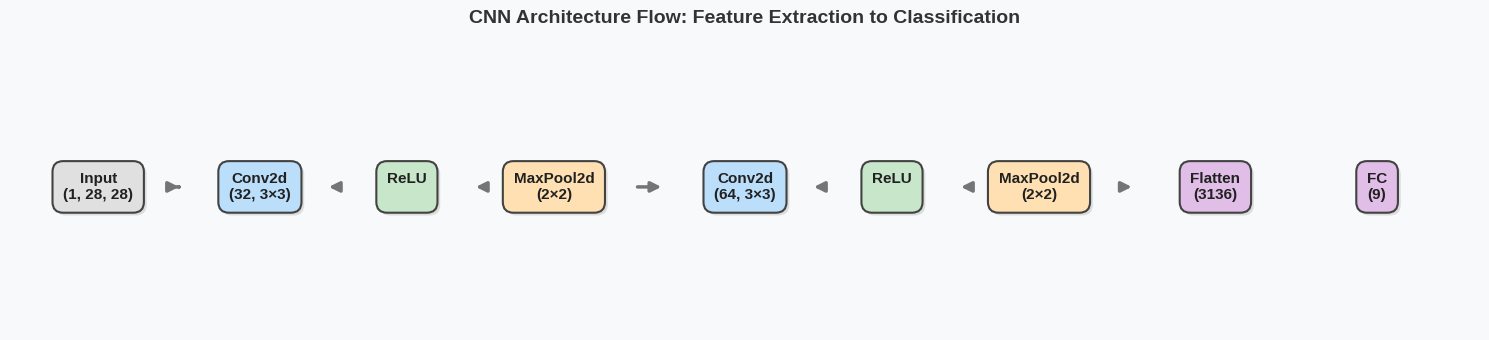

Saved highly visual version: /kaggle/working/cv-sudoku/notebook_outputs/architecture_flow.png


In [15]:
fig, ax = plt.subplots(figsize=(15, 3.5), facecolor='#f8f9fa')
ax.axis('off')

# Layer data: (Label, x_position, layer_type)
layers = [
    ('Input\n(1, 28, 28)', 0.06, 'input'),
    ('Conv2d\n(32, 3×3)', 0.17, 'conv'),
    ('ReLU\n', 0.27, 'act'),
    ('MaxPool2d\n(2×2)', 0.37, 'pool'),
    ('Conv2d\n(64, 3×3)', 0.50, 'conv'),
    ('ReLU\n', 0.60, 'act'),
    ('MaxPool2d\n(2×2)', 0.70, 'pool'),
    ('Flatten\n(3136)', 0.82, 'dense'),
    ('FC\n(9)', 0.93, 'dense')
]

# Color palette mapped to layer types
colors = {
    'input': '#e0e0e0',      # Light Gray
    'conv': '#bbdefb',       # Light Blue
    'act': '#c8e6c9',        # Light Green
    'pool': '#ffe0b2',       # Peach/Orange
    'dense': '#e1bee7'       # Light Purple
}

# Draw boxes
for label, x_pos, layer_type in layers:
    bbox = dict(boxstyle='round,pad=0.7', 
                facecolor=colors[layer_type], 
                edgecolor='#424242', 
                linewidth=1.5)
    
    text = ax.text(x_pos, 0.5, label, ha='center', va='center', 
                   fontsize=11, fontweight='bold', color='#212121',
                   bbox=bbox, transform=ax.transAxes)
    
    # Add a subtle drop shadow to the boxes
    text.get_bbox_patch().set_path_effects([
        path_effects.SimplePatchShadow(offset=(2, -2), alpha=0.15), 
        path_effects.Normal()
    ])

# Draw polished arrows between boxes
arrow_props = dict(arrowstyle='-|>', mutation_scale=15, lw=2.5, color='#757575')
for i in range(len(layers) - 1):
    x1_pos = layers[i][1] + 0.055  # Adjusted spacing for arrows
    x2_pos = layers[i + 1][1] - 0.055
    
    ax.annotate('', xy=(x2_pos, 0.5), xytext=(x1_pos, 0.5),
                arrowprops=arrow_props, xycoords='axes fraction', textcoords='axes fraction')

# Set titles and layout
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('CNN Architecture Flow: Feature Extraction to Classification', 
             fontsize=14, fontweight='heavy', color='#333333', pad=15)

plt.tight_layout()

# Save with a high DPI for a crisp look
save_path = os.path.join(output_dir, 'architecture_flow.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved highly visual version: {save_path}")


Layer-by-Layer Parameter Count:
       Layer  Parameters  Trainable
conv1.weight         288       True
  conv1.bias          32       True
conv2.weight       18432       True
  conv2.bias          64       True
   fc.weight       28224       True
     fc.bias           9       True

Total Parameters: 47,049


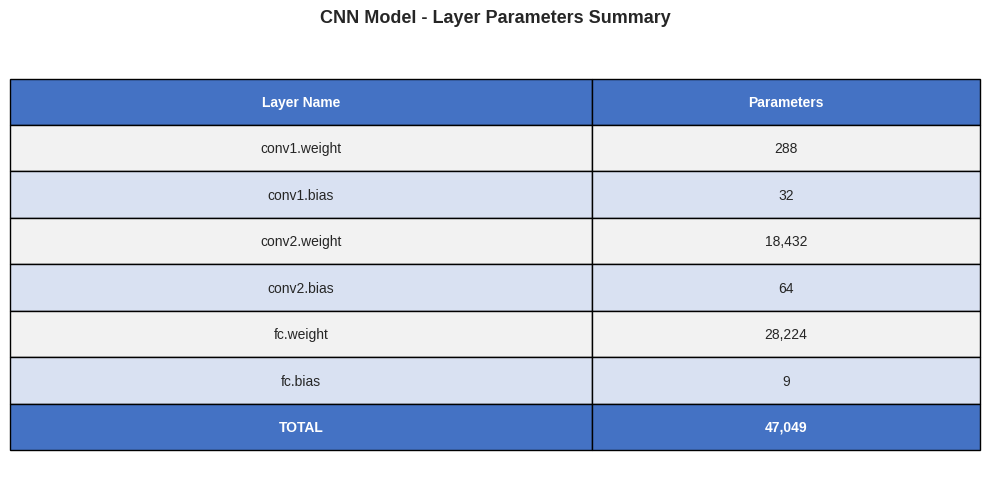


Saved: layer_parameters.png


In [16]:
# Visualization: Layer-by-layer parameter counts
layer_info = []
total_params = 0

for name, param in model.named_parameters():
    num_params = param.numel()
    total_params += num_params
    layer_info.append({
        'Layer': name,
        'Parameters': num_params,
        'Trainable': param.requires_grad
    })

df_layers = pd.DataFrame(layer_info)
print("\nLayer-by-Layer Parameter Count:")
print(df_layers.to_string(index=False))
print(f"\nTotal Parameters: {total_params:,}")

# Visualization table
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('tight')
ax.axis('off')

table_data = []
for _, row in df_layers.iterrows():
    table_data.append([row['Layer'], f"{row['Parameters']:,}"])
table_data.append(['TOTAL', f"{total_params:,}"])

table = ax.table(cellText=table_data,
                colLabels=['Layer Name', 'Parameters'],
                cellLoc='center',
                loc='center',
                colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

for i in range(len(table_data) + 1):
    if i == 0 or i == len(table_data):
        for j in range(2):
            table[(i, j)].set_facecolor('#4472C4')
            table[(i, j)].set_text_props(weight='bold', color='white')
    else:
        for j in range(2):
            table[(i, j)].set_facecolor('#D9E1F2' if i % 2 == 0 else '#F2F2F2')

ax.set_title('CNN Model - Layer Parameters Summary', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'layer_parameters.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: layer_parameters.png")

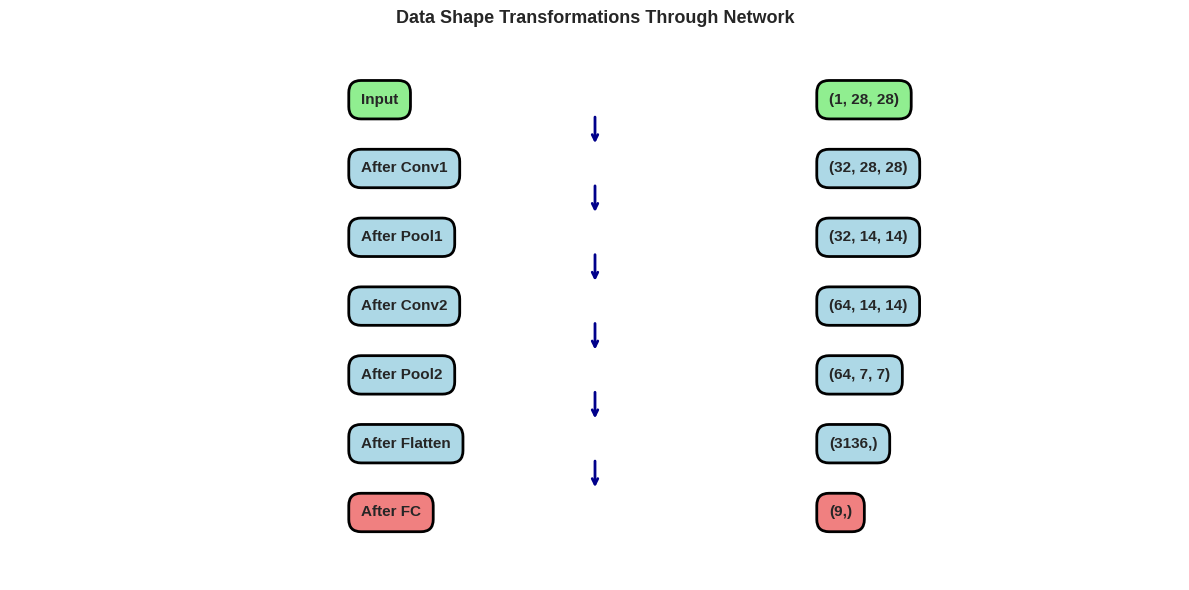

Saved: shape_transformations.png


In [17]:
# Visualization: Data shape transformations
shape_transforms = [
    ('Input', '(1, 28, 28)'),
    ('After Conv1', '(32, 28, 28)'),
    ('After Pool1', '(32, 14, 14)'),
    ('After Conv2', '(64, 14, 14)'),
    ('After Pool2', '(64, 7, 7)'),
    ('After Flatten', '(3136,)'),
    ('After FC', '(9,)')
]

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

y_pos = 0.9
for i, (stage, shape) in enumerate(shape_transforms):
    color = 'lightgreen' if i == 0 else 'lightcoral' if i == len(shape_transforms) - 1 else 'lightblue'
    bbox = dict(boxstyle='round,pad=0.8', facecolor=color, edgecolor='black', linewidth=2)
    ax.text(0.3, y_pos, stage, fontsize=11, fontweight='bold', bbox=bbox, transform=ax.transAxes)
    ax.text(0.7, y_pos, shape, fontsize=11, fontweight='bold', bbox=bbox, transform=ax.transAxes)

    if i < len(shape_transforms) - 1:
        ax.annotate('', xy=(0.5, y_pos - 0.08), xytext=(0.5, y_pos - 0.02),
                    arrowprops=dict(arrowstyle='->', lw=2, color='darkblue'),
                    xycoords='axes fraction', textcoords='axes fraction')

    y_pos -= 0.13

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Data Shape Transformations Through Network', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'shape_transformations.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shape_transformations.png")

## Section 4: Training Pipeline & Metrics

In [18]:
# Create data loaders
batch_size = 128
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

DataLoaders created:
  Train batches: 409
  Val batches: 75
  Test batches: 82


In [19]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch.
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch [{batch_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

def validate(model, val_loader, criterion, device):
    """
    Validate the model.
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

print("Training functions defined")

Training functions defined


In [21]:
# Training configuration
num_epochs = 10
learning_rate = 0.005

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'learning_rate': []
}

best_val_loss = float('inf')
best_epoch = 0
start_time = datetime.now()

print("Starting training...\n")

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])

    print(f"\nEpoch [{epoch + 1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_model_path = os.path.join(model_save_dir, 'best_model.pt')
        torch.save(model.state_dict(), best_model_path)
        print(f"  Saved best model")

training_time = datetime.now() - start_time
print(f"\nTraining complete. Time: {training_time}")

Starting training...

  Batch [50/409], Loss: 0.2032
  Batch [100/409], Loss: 0.1342
  Batch [150/409], Loss: 0.1411
  Batch [200/409], Loss: 0.0803
  Batch [250/409], Loss: 0.0417
  Batch [300/409], Loss: 0.1387
  Batch [350/409], Loss: 0.1160
  Batch [400/409], Loss: 0.1755

Epoch [1/10]
  Train Loss: 0.2122, Train Acc: 93.33%
  Val Loss: 0.0827, Val Acc: 97.51%
  Saved best model
  Batch [50/409], Loss: 0.0602
  Batch [100/409], Loss: 0.1497
  Batch [150/409], Loss: 0.0279
  Batch [200/409], Loss: 0.1374
  Batch [250/409], Loss: 0.0392
  Batch [300/409], Loss: 0.0600
  Batch [350/409], Loss: 0.0336
  Batch [400/409], Loss: 0.0544

Epoch [2/10]
  Train Loss: 0.0825, Train Acc: 97.37%
  Val Loss: 0.0552, Val Acc: 98.34%
  Saved best model
  Batch [50/409], Loss: 0.0495
  Batch [100/409], Loss: 0.0972
  Batch [150/409], Loss: 0.0615
  Batch [200/409], Loss: 0.0392
  Batch [250/409], Loss: 0.2125
  Batch [300/409], Loss: 0.0142
  Batch [350/409], Loss: 0.0874
  Batch [400/409], Loss: 0.

In [22]:
# Test evaluation
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"\nTest Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

# Save final model
timestamp = datetime.now().strftime("%d_%m_%Y_%H_%M_%S")
model_path = os.path.join(model_save_dir, f'model_{timestamp}.pt')
torch.save(model.state_dict(), model_path)
print(f"Model saved at: {model_path}")

# Save checkpoint
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_loss': test_loss,
    'test_accuracy': test_acc,
}
checkpoint_path = os.path.join(model_save_dir, f'checkpoint_{timestamp}.pt')
torch.save(checkpoint, checkpoint_path)
print(f"Checkpoint saved at: {checkpoint_path}")


Test Loss: 0.0284, Test Acc: 99.01%
Model saved at: /kaggle/working/cv-sudoku/models/model_28_05_2026_15_40_09.pt
Checkpoint saved at: /kaggle/working/cv-sudoku/models/checkpoint_28_05_2026_15_40_09.pt


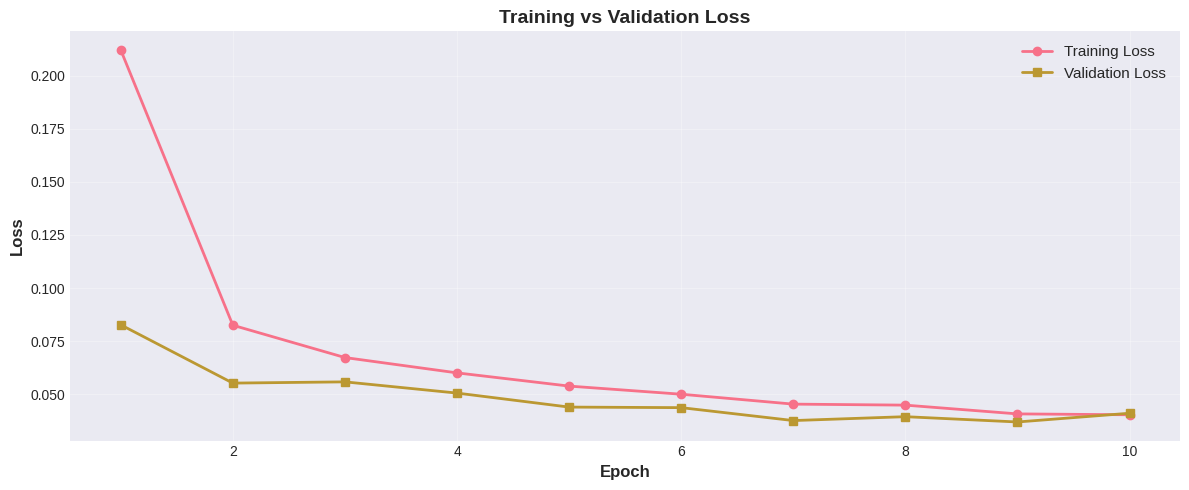

Saved: loss_curve.png


In [23]:
# Visualization: Training vs Validation Loss curve
fig, ax = plt.subplots(figsize=(12, 5))
epochs_range = range(1, num_epochs + 1)

ax.plot(epochs_range, history['train_loss'], marker='o', label='Training Loss', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_loss'], marker='s', label='Validation Loss', linewidth=2, markersize=6)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'loss_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_curve.png")

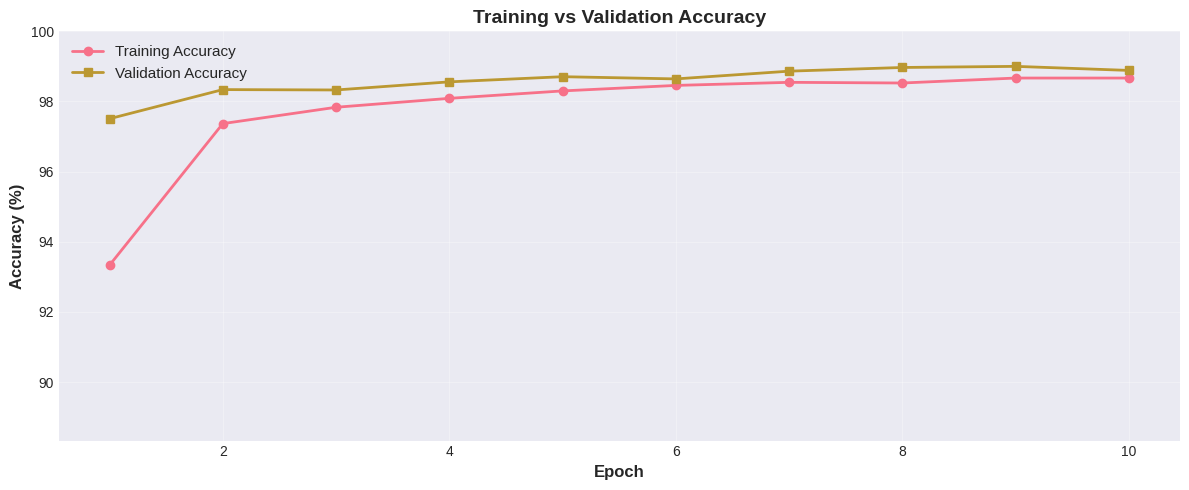

Saved: accuracy_curve.png


In [24]:
# Visualization: Training vs Validation Accuracy curve
fig, ax = plt.subplots(figsize=(12, 5))
epochs_range = range(1, num_epochs + 1)

ax.plot(epochs_range, history['train_acc'], marker='o', label='Training Accuracy', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_acc'], marker='s', label='Validation Accuracy', linewidth=2, markersize=6)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3)
ax.set_ylim([min(history['train_acc'] + history['val_acc']) - 5, 100])

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'accuracy_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: accuracy_curve.png")

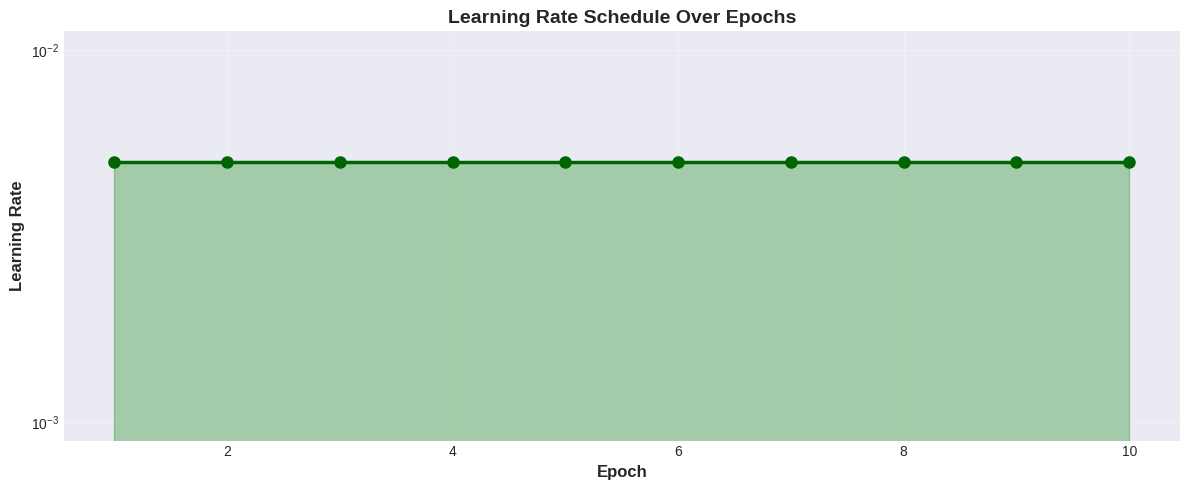

Saved: learning_rate_schedule.png


In [25]:
# Visualization: Learning rate schedule visualization
fig, ax = plt.subplots(figsize=(12, 5))
epochs_range = range(1, len(history['learning_rate']) + 1)

ax.plot(epochs_range, history['learning_rate'], marker='o', linewidth=2.5, markersize=8, color='darkgreen')
ax.fill_between(epochs_range, history['learning_rate'], alpha=0.3, color='green')

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
ax.set_title('Learning Rate Schedule Over Epochs', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'learning_rate_schedule.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: learning_rate_schedule.png")

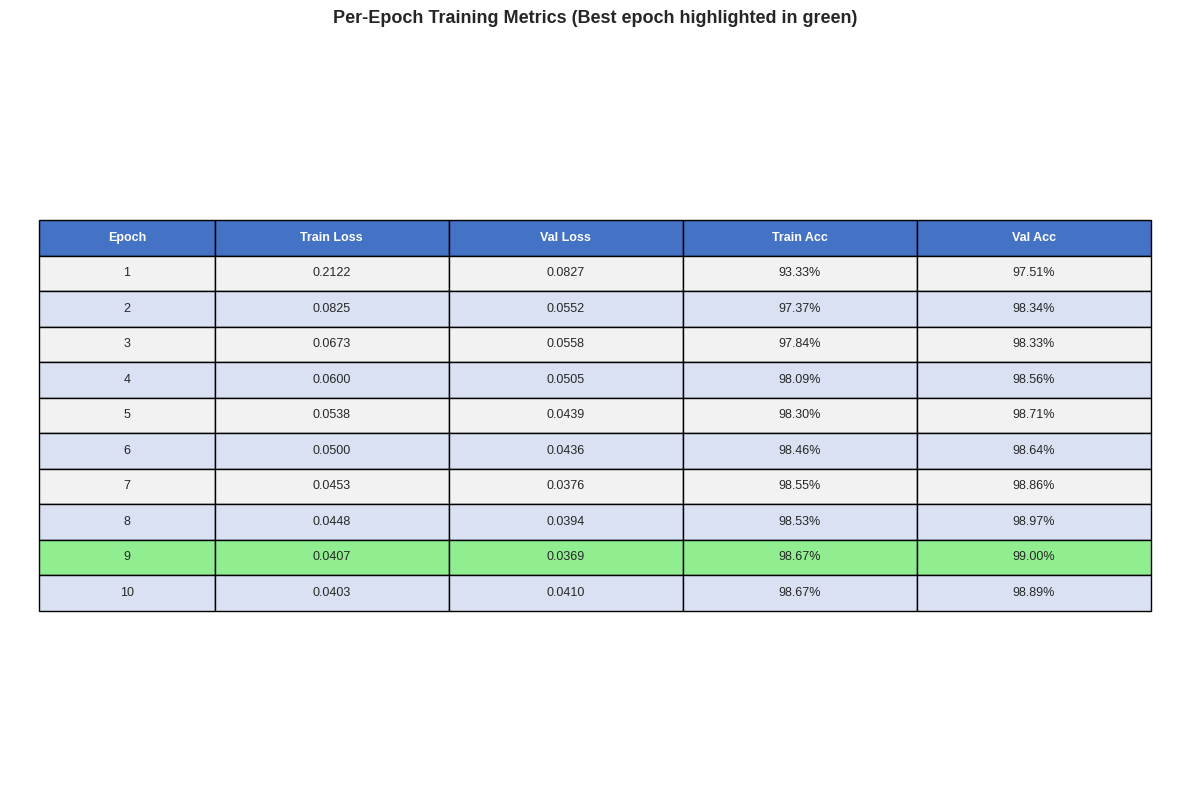

Saved: metrics_table.png


In [26]:
# Visualization: Per-epoch metrics table
metrics_data = []
for epoch in range(num_epochs):
    metrics_data.append([
        epoch + 1,
        f"{history['train_loss'][epoch]:.4f}",
        f"{history['val_loss'][epoch]:.4f}",
        f"{history['train_acc'][epoch]:.2f}%",
        f"{history['val_acc'][epoch]:.2f}%"
    ])

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=metrics_data,
                colLabels=['Epoch', 'Train Loss', 'Val Loss', 'Train Acc', 'Val Acc'],
                cellLoc='center',
                loc='center',
                colWidths=[0.15, 0.2, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

for i in range(len(metrics_data) + 1):
    for j in range(5):
        cell = table[(i, j)]
        if i == 0:
            cell.set_facecolor('#4472C4')
            cell.set_text_props(weight='bold', color='white')
        else:
            cell.set_facecolor('#D9E1F2' if i % 2 == 0 else '#F2F2F2')
            if i - 1 == best_epoch:
                cell.set_facecolor('#90EE90')

ax.set_title('Per-Epoch Training Metrics (Best epoch highlighted in green)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'metrics_table.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: metrics_table.png")

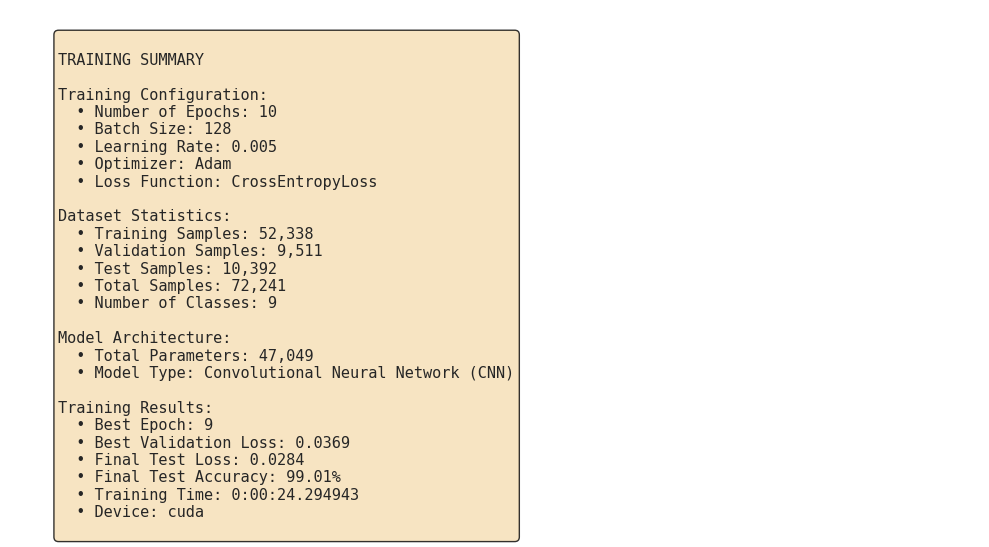

Saved: training_summary.png


In [27]:
# Visualization: Final model statistics
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

stats_text = f"""
TRAINING SUMMARY

Training Configuration:
  • Number of Epochs: {num_epochs}
  • Batch Size: {batch_size}
  • Learning Rate: {learning_rate}
  • Optimizer: Adam
  • Loss Function: CrossEntropyLoss

Dataset Statistics:
  • Training Samples: {x_train.shape[0]:,}
  • Validation Samples: {x_val.shape[0]:,}
  • Test Samples: {x_test.shape[0]:,}
  • Total Samples: {x_train.shape[0] + x_val.shape[0] + x_test.shape[0]:,}
  • Number of Classes: 9

Model Architecture:
  • Total Parameters: {total_params:,}
  • Model Type: Convolutional Neural Network (CNN)

Training Results:
  • Best Epoch: {best_epoch + 1}
  • Best Validation Loss: {best_val_loss:.4f}
  • Final Test Loss: {test_loss:.4f}
  • Final Test Accuracy: {test_acc:.2f}%
  • Training Time: {training_time}
  • Device: {device}
"""

ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'training_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_summary.png")

## Section 5: Model Evaluation & Error Analysis

In [28]:
# Load best model for evaluation
model.load_state_dict(torch.load(os.path.join(model_save_dir, 'best_model.pt')))
model.eval()

# Get predictions on test set
all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        outputs = model(data)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)

print("Predictions generated for evaluation")

Predictions generated for evaluation


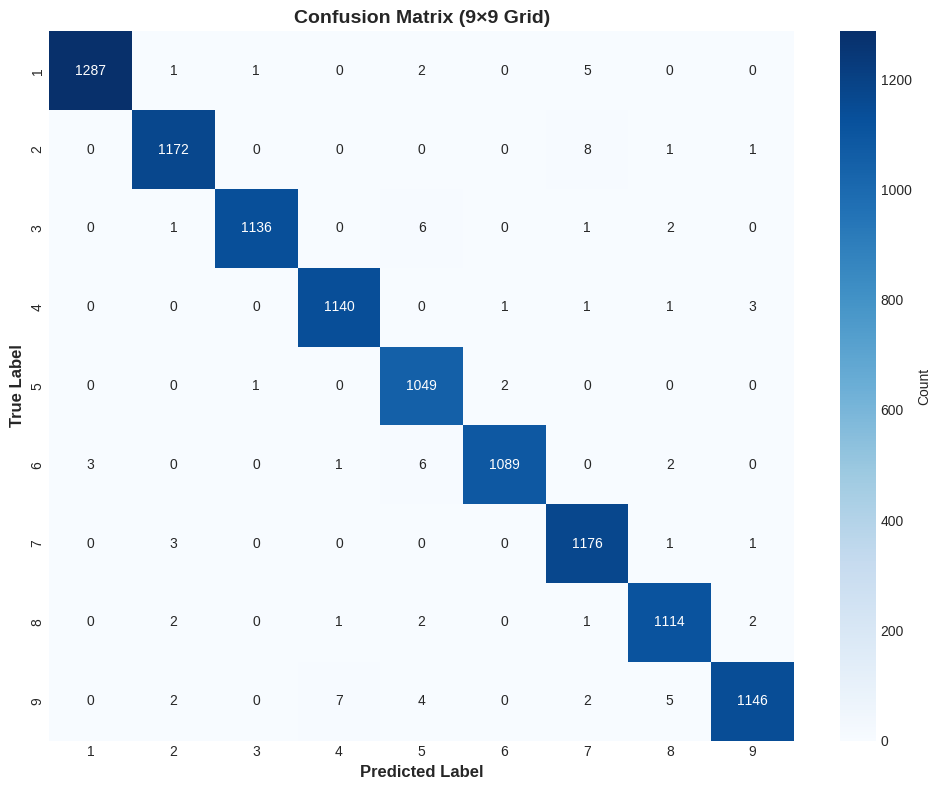

Saved: confusion_matrix.png


In [29]:
# Visualization: Confusion matrix heatmap
cm = confusion_matrix(all_targets, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=[f'{i}' for i in range(1, 10)],
            yticklabels=[f'{i}' for i in range(1, 10)],
            cbar_kws={'label': 'Count'})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix (9×9 Grid)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

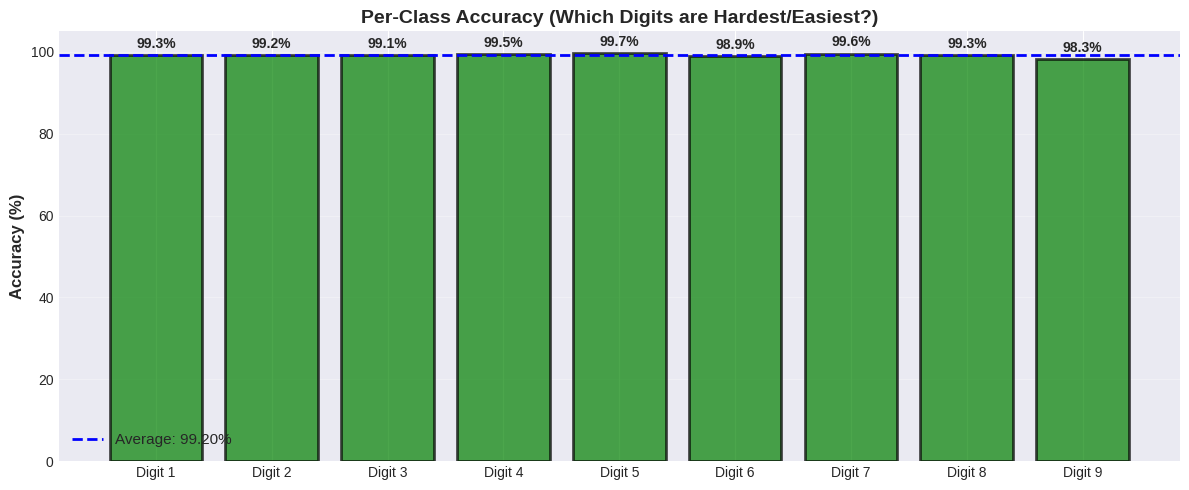

Saved: per_class_accuracy.png


In [30]:
# Visualization: Per-class accuracy bar chart
class_accuracy = []
for digit in range(9):
    mask = all_targets == digit
    if mask.sum() > 0:
        acc = (all_preds[mask] == all_targets[mask]).sum() / mask.sum() * 100
        class_accuracy.append(acc)
    else:
        class_accuracy.append(0)

fig, ax = plt.subplots(figsize=(12, 5))
digits = [f'Digit {i}' for i in range(1, 10)]
colors = ['green' if acc >= 95 else 'orange' if acc >= 85 else 'red' for acc in class_accuracy]

bars = ax.bar(digits, class_accuracy, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(y=np.mean(class_accuracy), color='blue', linestyle='--', linewidth=2, label=f'Average: {np.mean(class_accuracy):.2f}%')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Accuracy (Which Digits are Hardest/Easiest?)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 105])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add accuracy labels on bars
for bar, acc in zip(bars, class_accuracy):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'per_class_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_class_accuracy.png")

In [31]:
# Get misclassified examples
misclassified_indices = np.where(all_preds != all_targets)[0]
correctly_classified_indices = np.where(all_preds == all_targets)[0]

# Get confidence scores for each prediction
max_probs = np.max(all_probs, axis=1)
misclassified_confidences = max_probs[misclassified_indices]
correctly_classified_confidences = max_probs[correctly_classified_indices]

# Sort by confidence to get worst predictions
sorted_misclassified_idx = misclassified_indices[np.argsort(misclassified_confidences)]
sorted_correct_idx = correctly_classified_indices[np.argsort(-correctly_classified_confidences)]

print(f"Total test samples: {len(all_targets)}")
print(f"Misclassified: {len(misclassified_indices)} ({len(misclassified_indices)/len(all_targets)*100:.2f}%)")
print(f"Correctly classified: {len(correctly_classified_indices)} ({len(correctly_classified_indices)/len(all_targets)*100:.2f}%)")

Total test samples: 10392
Misclassified: 83 (0.80%)
Correctly classified: 10309 (99.20%)


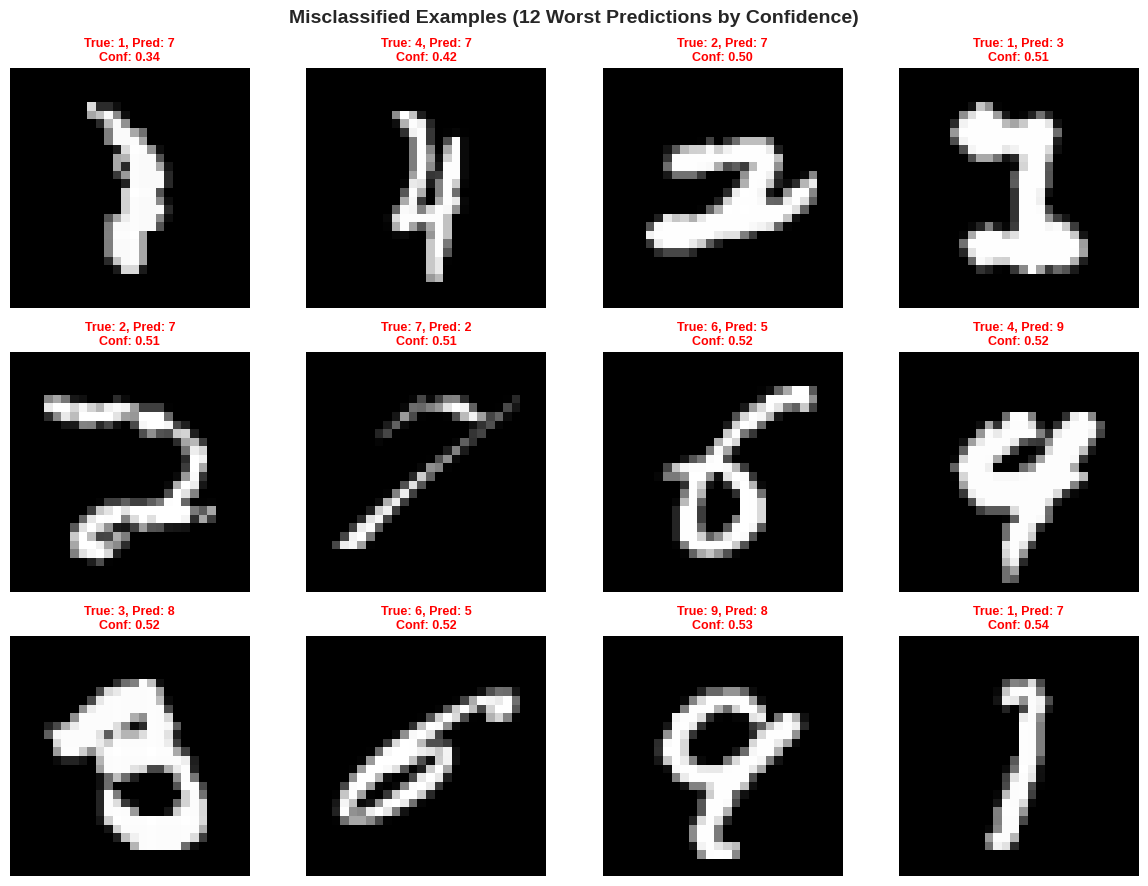

Saved: misclassified_examples.png


In [32]:
# Visualization: Misclassified examples gallery (12 worst predictions)
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle('Misclassified Examples (12 Worst Predictions by Confidence)', fontsize=14, fontweight='bold')

n_worst = min(12, len(sorted_misclassified_idx))
worst_indices = sorted_misclassified_idx[:n_worst]

for idx, test_idx in enumerate(worst_indices):
    ax = axes[idx // 4, idx % 4]

    img = x_test[test_idx, 0].numpy()
    true_label = all_targets[test_idx]
    pred_label = all_preds[test_idx]
    confidence = max_probs[test_idx]

    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {true_label+1}, Pred: {pred_label+1}\nConf: {confidence:.2f}',
                fontsize=9, color='red', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'misclassified_examples.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: misclassified_examples.png")

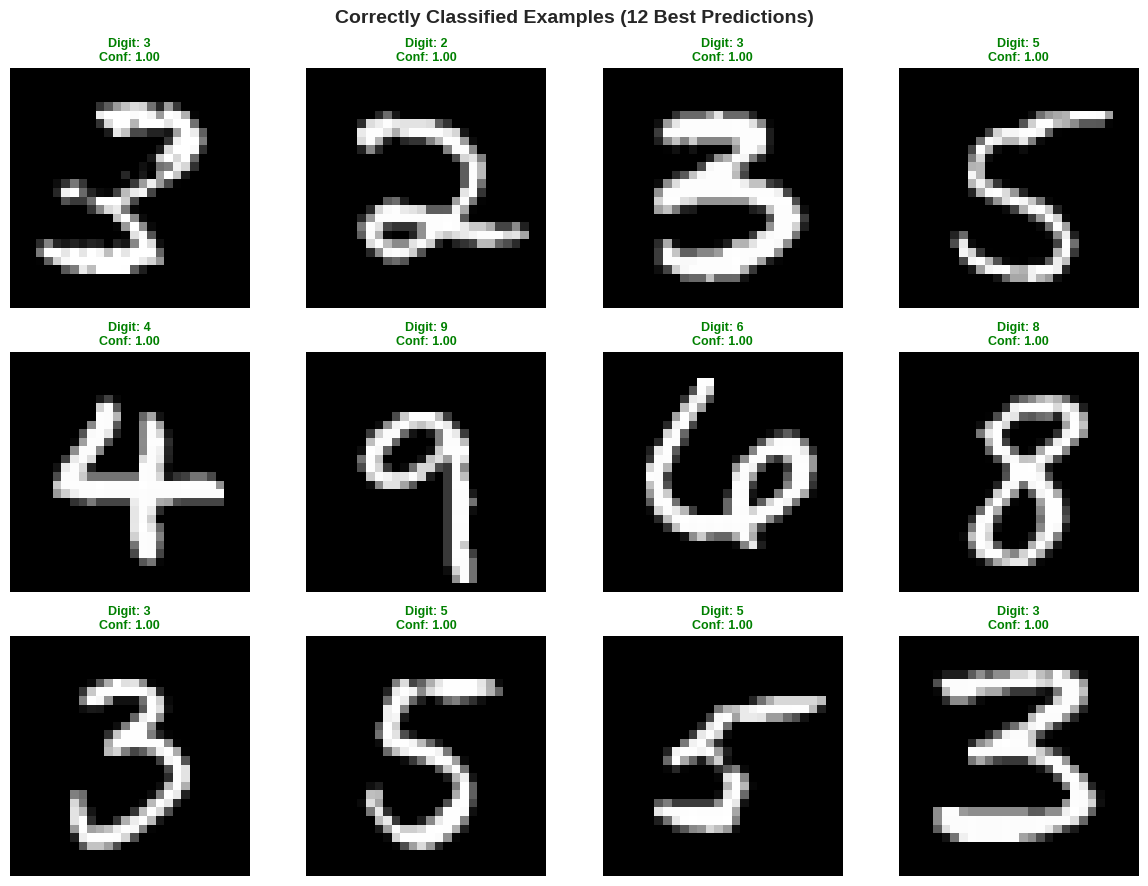

Saved: correct_examples.png


In [33]:
# Visualization: Correctly classified examples (12 best predictions)
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle('Correctly Classified Examples (12 Best Predictions)', fontsize=14, fontweight='bold')

n_best = min(12, len(sorted_correct_idx))
best_indices = sorted_correct_idx[:n_best]

for idx, test_idx in enumerate(best_indices):
    ax = axes[idx // 4, idx % 4]

    img = x_test[test_idx, 0].numpy()
    true_label = all_targets[test_idx]
    confidence = max_probs[test_idx]

    ax.imshow(img, cmap='gray')
    ax.set_title(f'Digit: {true_label+1}\nConf: {confidence:.2f}',
                fontsize=9, color='green', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'correct_examples.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: correct_examples.png")

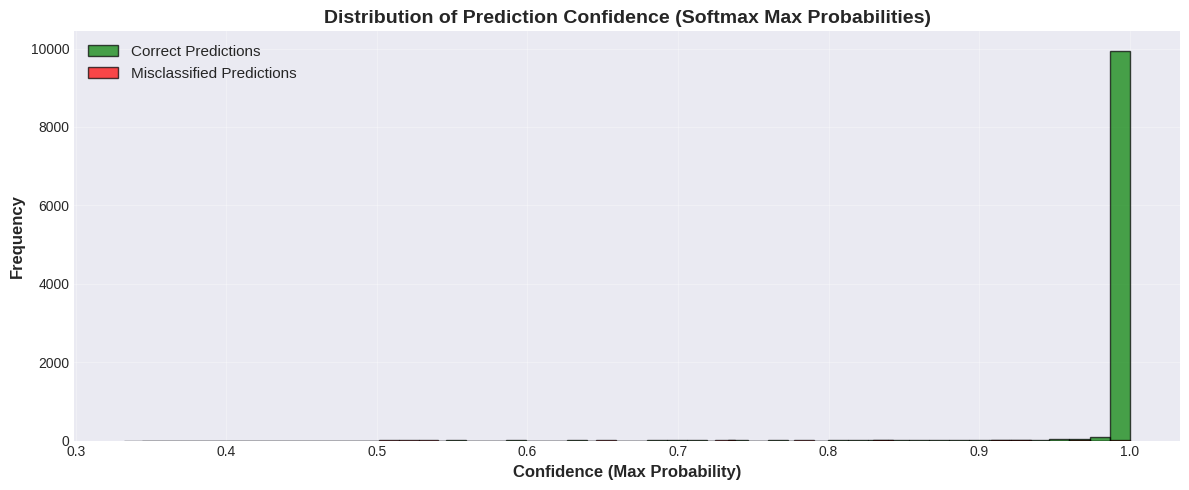

Saved: confidence_distribution.png


In [34]:
# Visualization: Confidence distribution histogram
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(correctly_classified_confidences, bins=50, label='Correct Predictions',
        alpha=0.7, color='green', edgecolor='black')
ax.hist(misclassified_confidences, bins=50, label='Misclassified Predictions',
        alpha=0.7, color='red', edgecolor='black')

ax.set_xlabel('Confidence (Max Probability)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Prediction Confidence (Softmax Max Probabilities)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'confidence_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confidence_distribution.png")

## Section 6: Image Processing & Grid Detection Utilities

Here we define utility functions for sudoku image processing, grid detection, and cell extraction.

In [63]:
# Image processing utility functions

def resize_and_maintain_aspect_ratio(input_image, new_width):
    """
    Resize image while maintaining aspect ratio.
    """
    orig_width, orig_height = input_image.shape[1], input_image.shape[0]
    ratio = new_width / float(orig_width)
    new_height = int(orig_height * ratio)
    dim = (new_width, new_height)
    reshaped_image = cv2.resize(input_image, dim, interpolation=cv2.INTER_AREA)
    return reshaped_image

def apply_grayscale_blur_and_threshold(img, method="mean", blocksize=91, c=7):
    """
    Convert RGB to thresholded image.
    """
    img = cv2.GaussianBlur(img, ksize=(3, 3), sigmaX=0)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    if method == "mean":
        adaptiveMethod = cv2.ADAPTIVE_THRESH_MEAN_C
    else:
        adaptiveMethod = cv2.ADAPTIVE_THRESH_GAUSSIAN_C

    thresh = cv2.adaptiveThreshold(gray, maxValue=255,
                                    adaptiveMethod=adaptiveMethod,
                                    thresholdType=cv2.THRESH_BINARY,
                                    blockSize=blocksize, C=c)
    thresh = cv2.bitwise_not(thresh)
    return thresh

def get_quadrilateral_points_in_order(approx_arr):
    """
    Order quadrilateral points (TL, TR, BR, BL).
    """
    if approx_arr.shape == (4, 1, 2):
        approx_arr = np.squeeze(approx_arr, axis=1)

    max_x = int(1.1 * np.max(approx_arr[:, 0]))
    origin_1 = [0, 0]
    origin_2 = [max_x, 0]

    distances_1 = [np.linalg.norm(point - origin_1) for point in approx_arr]
    distances_2 = [np.linalg.norm(point - origin_2) for point in approx_arr]

    tl_idx = np.argmin(distances_1)
    br_idx = np.argmax(distances_1)

    dist_arr = distances_2.copy()
    dist_arr[tl_idx] = np.inf
    dist_arr[br_idx] = np.inf
    tr_idx = np.argmin(dist_arr)

    dist_arr = distances_2.copy()
    dist_arr[tl_idx] = -np.inf
    dist_arr[br_idx] = -np.inf
    bl_idx = np.argmax(dist_arr)

    tl = approx_arr[tl_idx]
    br = approx_arr[br_idx]
    tr = approx_arr[tr_idx]
    bl = approx_arr[bl_idx]

    return np.array([tl, tr, br, bl])

def perform_four_point_transform(input_img, src_corners, pad=10):
    """
    Perform perspective transform.
    """
    src_corners = get_quadrilateral_points_in_order(src_corners)
    src_corners = src_corners.astype('float32')
    tl, tr, br, bl = src_corners

    bottom_width = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    top_width = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    max_width = max(int(bottom_width), int(top_width))

    left_height = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    right_height = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    max_height = max(int(left_height), int(right_height))

    dest_img_corners = np.array([[0+pad, 0+pad],
                                 [max_width-1-pad, 0+pad],
                                 [max_width-1-pad, max_height-1-pad],
                                 [0+pad, max_height-1-pad]], dtype='float32')

    M = cv2.getPerspectiveTransform(src=src_corners, dst=dest_img_corners)
    warped_img = cv2.warpPerspective(input_img, M, (max_width, max_height))

    return M, warped_img

def center_and_resize_digit(cell_img):
    """
    Finds the digit in the cell, crops it, and centers it in a 28x28 black canvas 
    (similar to MNIST dataset formatting).
    """
    contours, _ = cv2.findContours(cell_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return cv2.resize(cell_img, (28, 28), interpolation=cv2.INTER_AREA)

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    digit = cell_img[y:y+h, x:x+w]

    max_side = max(w, h)
    if max_side == 0:
        return cv2.resize(cell_img, (28, 28))
        
    scale = 20.0 / max_side
    new_w = int(w * scale)
    new_h = int(h * scale)
    
    if new_w <= 0 or new_h <= 0:
        return cv2.resize(cell_img, (28, 28))

    resized_digit = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.zeros((28, 28), dtype=np.uint8)

    start_y = (28 - new_h) // 2
    start_x = (28 - new_w) // 2

    canvas[start_y:start_y+new_h, start_x:start_x+new_w] = resized_digit

    return canvas

print("Image processing utilities defined")

Image processing utilities defined


In [36]:
def find_grid_contour_candidates(img):
    """
    Find potential sudoku grid contours.
    """
    M_matrices = []
    warped_images = []
    contour_grid_candidates = []

    img_area = img.shape[0] * img.shape[1]
    thresh = apply_grayscale_blur_and_threshold(img, blocksize=41, c=8)

    contours = cv2.findContours(image=thresh.copy(),
                                mode=cv2.RETR_EXTERNAL,
                                method=cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        contours = imutils.grab_contours(contours)
        contours = sorted(contours, key=cv2.contourArea, reverse=True)

        for contour in contours:
            perimeter = cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, 0.03 * perimeter, True)

            contour_area = cv2.contourArea(contour)
            contour_fractional_area = contour_area / img_area

            if len(approx) == 4 and contour_fractional_area > 0.1:
                approx = get_quadrilateral_points_in_order(approx)
                M, warped_img = perform_four_point_transform(input_img=img,
                                                              src_corners=approx,
                                                              pad=30)

                M_matrices.append(M)
                warped_images.append(warped_img)
                contour_grid_candidates.append(contour)

    if warped_images:
        return M_matrices, warped_images, contour_grid_candidates
    else:
        return None, None, None

def check_for_digit_in_cell_image(img, area_threshold=5, apply_border=False):
    """
    Check if digit is present in cell.
    """
    cell_img = img.copy()

    if apply_border:
        border_fraction = 0.07
        replacement_val = 0

        y_border_px = int(border_fraction * cell_img.shape[0])
        x_border_px = int(border_fraction * cell_img.shape[1])

        cell_img[:, 0:x_border_px] = replacement_val
        cell_img[:, -x_border_px:] = replacement_val
        cell_img[0:y_border_px, :] = replacement_val
        cell_img[-y_border_px:, :] = replacement_val

    contours = cv2.findContours(image=cell_img,
                                mode=cv2.RETR_TREE,
                                method=cv2.CHAIN_APPROX_SIMPLE)
    contours = imutils.grab_contours(contours)

    if len(contours) > 0:
        contours = sorted(contours, key=cv2.contourArea, reverse=True)
        largest_contour_area = cv2.contourArea(contours[0])
        image_area = cell_img.shape[0] * cell_img.shape[1]
        contour_percentage_area = 100 * largest_contour_area / image_area

        if contour_percentage_area > area_threshold:
            image_contains_digit = True
        else:
            image_contains_digit = False
    else:
        image_contains_digit = False

    return image_contains_digit, cell_img

print("Advanced image processing utilities defined")

Advanced image processing utilities defined


In [64]:
def locate_cells_within_grid(grid_img):
    """
    Identify individual sudoku cells.
    """
    valid_cells = []
    grid_area = grid_img.shape[0] * grid_img.shape[1]

    grid_img = apply_grayscale_blur_and_threshold(grid_img, method="mean", blocksize=91, c=7)

    contours = cv2.findContours(image=grid_img.copy(),
                                mode=cv2.RETR_TREE,
                                method=cv2.CHAIN_APPROX_NONE)

    if contours:
        contours = imutils.grab_contours(contours)
        contours = sorted(contours, key=cv2.contourArea, reverse=True)

        for contour in contours:
            perimeter = cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, 0.03 * perimeter, True)
            contour_fractional_area = cv2.contourArea(contour) / grid_area

            if len(approx) == 4 and contour_fractional_area > 0.005 and contour_fractional_area < 0.015:
                mask = np.zeros_like(grid_img)
                cv2.drawContours(image=mask,
                                contours=[contour],
                                contourIdx=0,
                                color=255,
                                thickness=cv2.FILLED)

                y_px, x_px = np.where(mask==255)
                cell_image = grid_img[min(y_px):max(y_px)+1, min(x_px):max(x_px)+1]
                # digit_is_present, cell_image = check_for_digit_in_cell_image(img=cell_image,
                #                                                              area_threshold=5,
                #                                                              apply_border=True)

                # kernel = np.ones((3, 3), np.uint8)
                # cell_image = cv2.erode(cell_image, kernel, iterations=1)
                # cell_image = cv2.resize(cell_image, dsize=(28, 28), interpolation=cv2.INTER_AREA)

                digit_is_present, cell_image = check_for_digit_in_cell_image(img=cell_image,
                                                                             area_threshold=5,
                                                                             apply_border=True)

                kernel = np.ones((3, 3), np.uint8)
                cell_image = cv2.erode(cell_image, kernel, iterations=1)
                
                if digit_is_present:
                    cell_image = center_and_resize_digit(cell_image)
                else:
                    cell_image = np.zeros((28, 28), dtype=np.uint8)
                
                moments = cv2.moments(contour)
                x_centroid = int(moments['m10'] / moments['m00'])
                y_centroid = int(moments['m01'] / moments['m00'])

                valid_cells.append({'img': cell_image,
                                    'contains_digit': digit_is_present,
                                    'x_centroid': x_centroid,
                                    'y_centroid': y_centroid})

    return valid_cells

print("Cell location utilities defined")

Cell location utilities defined


In [75]:
# def sort_cells_into_grid(cells):
#     """
#     Sort cells into original puzzle grid order.
#     """
#     x_vals = [cell['x_centroid'] for cell in cells]
#     y_vals = [cell['y_centroid'] for cell in cells]

#     points = np.array([[cell['x_centroid'], cell['y_centroid']] for cell in cells])
#     points_sorted = np.array(sorted(points, key=lambda x: x[1]))
    
#     rows = np.reshape(points_sorted, (9, 9, 2))
    
#     final = np.array([sorted(row, key=lambda x: x[0]) for row in rows])

#     final_reshaped = np.reshape(final, (81, 2))

#     indices = []
#     for x, y in final_reshaped:
#         x_indices = np.where(np.array(x_vals) == x)
#         y_indices = np.where(np.array(y_vals) == y)
#         index = np.intersect1d(x_indices, y_indices)[0]
#         indices.append(index)

#     sorted_cells_list = [cells[idx] for idx in indices]
#     return sorted_cells_list

def sort_cells_into_grid(cells):
    max_x = max([cell['x_centroid'] for cell in cells])
    max_y = max([cell['y_centroid'] for cell in cells])
    
    grid_width = max_x * 1.1 
    grid_height = max_y * 1.1
    
    cell_w = grid_width / 9.0
    cell_h = grid_height / 9.0

    for cell in cells:
        row = int(cell['y_centroid'] / cell_h)
        col = int(cell['x_centroid'] / cell_w)
        
        cell['grid_row'] = min(row, 8)
        cell['grid_col'] = min(col, 8)

    sorted_cells = sorted(cells, key=lambda c: (c['grid_row'], c['grid_col']))
    return sorted_cells

def get_valid_cells_from_image(img):
    """
    Main function to extract valid cells from sudoku image.
    """
    M_matrices, warped_images, grid_candidates = find_grid_contour_candidates(img)

    if not warped_images:
        raise Exception("No grid candidates found")

    for i, grid_image in enumerate(warped_images):
        valid_cells = locate_cells_within_grid(grid_image)
        M = M_matrices[i]
        if len(valid_cells) == 81:
            valid_cells = sort_cells_into_grid(valid_cells)
            return valid_cells, M, grid_image

    raise Exception("Unable to find required number of cells")

print("Cell sorting and validation utilities defined")

Cell sorting and validation utilities defined


In [53]:
def plot_cell_images_in_grid(cells):
    """
    Plot all cells in 9x9 grid layout.
    """
    width, height = 9*28, 9*28
    main_img = np.zeros((height, width))

    for i, cell in enumerate(cells):
        row, col = np.array(divmod(i, 9))
        cell_image = cells[i]['img'].copy()
        main_img[row*28:(row+1)*28, col*28:(col+1)*28] = cell_image

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(main_img, cmap='gray')
    ax.set_title('Extracted and Sorted 81 Cells (9×9 Grid Layout)', fontweight='bold')
    ax.axis('off')
    return fig

def get_predicted_sudoku_grid_torch(model, cells, device):
    """
    Use PyTorch model to predict sudoku grid.
    """
    digit_images = np.array([cell['img'] for cell in cells if cell['contains_digit']])

    if len(digit_images) == 0:
        grid_array = np.zeros((81), dtype=int)
        
        grid_array = np.reshape(grid_array, (9, 9))
        
        return grid_array

    tensor_images = torch.from_numpy(digit_images).float()
    tensor_images = tensor_images.unsqueeze(1)
    tensor_images = tensor_images.to(device)

    with torch.no_grad():
        outputs = model(tensor_images)
        pred_labels = torch.argmax(outputs, dim=1).cpu().numpy() + 1

    indices = np.where([cell['contains_digit'] for cell in cells])[0]
    grid_array = np.zeros((81), dtype=int)
    grid_array[indices] = pred_labels
    
    grid_array = np.reshape(grid_array, (9, 9))
    
    return grid_array

print("Prediction and visualization utilities defined")

Prediction and visualization utilities defined


## Section 7: Sudoku Solver Class

In [40]:
class SudokuSolver():
    """
    Sudoku puzzle solver using backtracking algorithm.
    """
    def __init__(self, board):
        self.board = board

    def find_next_empty(self, empty_val=0):
        """
        Find next empty cell.
        """
        num_rows = len(self.board)
        num_cols = len(self.board[0])

        for row in range(num_rows):
            for col in range(num_cols):
                if self.board[row][col] == empty_val:
                    return (row, col)
        return None

    def is_valid_number(self, board, number, position):
        """
        Check if number is valid at position.
        """
        num_rows = len(board)
        square_size = int(math.sqrt(num_rows))
        row_idx, col_idx = position

        if number in board[row_idx]:
            return False

        current_column_values = [board[row][col_idx] for row in range(num_rows)]
        if number in current_column_values:
            return False

        square_x_idx = col_idx // square_size
        square_y_idx = row_idx // square_size
        for row in range(square_y_idx * square_size, (square_y_idx * square_size) + square_size):
            for col in range(square_x_idx * square_size, (square_x_idx * square_size) + square_size):
                if board[row][col] == number and (row, col) != position:
                    return False

        return True

    def solve(self):
        """
        Solve sudoku using backtracking.
        """
        next_empty_pos = self.find_next_empty()

        if not next_empty_pos:
            return True
        else:
            row, col = next_empty_pos

        for i in range(1, 10):
            if self.is_valid_number(board=self.board, number=i, position=(row, col)):
                self.board[row][col] = i
                if self.solve():
                    return True

        self.board[row][col] = 0
        return False

    def print_board(self):
        """
        Print sudoku board in readable format.
        """
        num_rows = len(self.board)
        square_size = int(math.sqrt(num_rows))

        for row in range(num_rows):
            if row != 0 and row % square_size == 0:
                print("- " * (num_rows + square_size - 1))

            for col in range(num_rows):
                if col != 0 and col % square_size == 0:
                    print("| ", end="")

                number = self.board[row][col]
                if col < num_rows - 1:
                    print(f"{number} ", end="")
                else:
                    print(number)

print("Sudoku Solver class defined")

Sudoku Solver class defined


## Section 8: End-to-End Sudoku Solving Example

Load a test sudoku image and demonstrate the complete solving pipeline.

In [67]:
# List available sudoku images
sudoku_images_dir = os.path.join(data_path, 'sudoku-images/sudoku_images')
if os.path.exists(sudoku_images_dir):
    image_files = glob.glob(os.path.join(sudoku_images_dir, '*.jpg')) + \
                  glob.glob(os.path.join(sudoku_images_dir, '*.png'))
    print(f"Found {len(image_files)} sudoku images")
else:
    print("No sudoku images directory found")

Found 26 sudoku images


Processing: 5.jpg


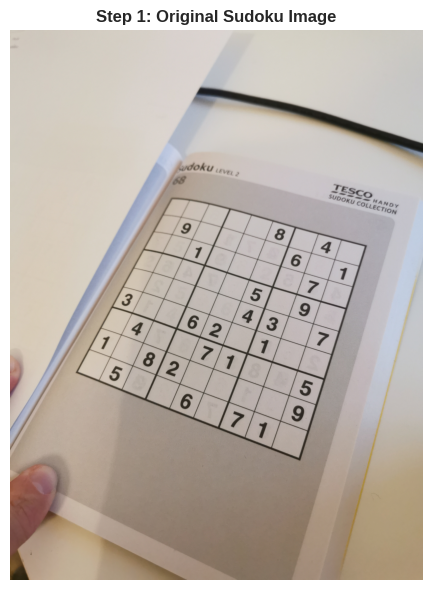

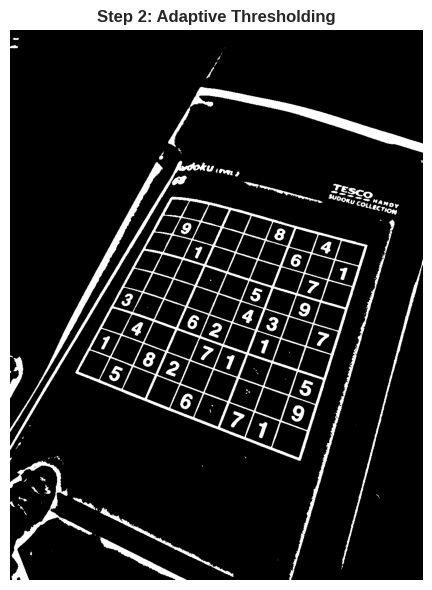

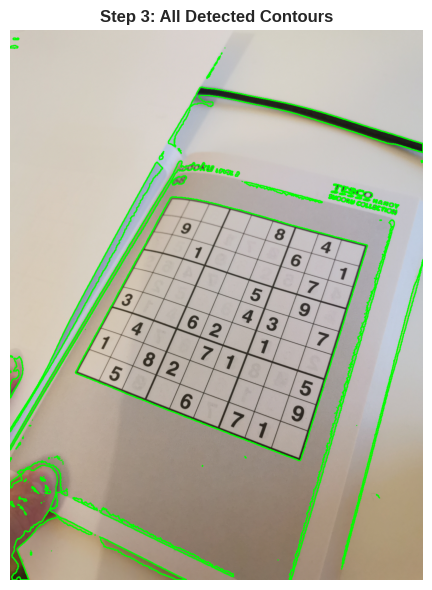

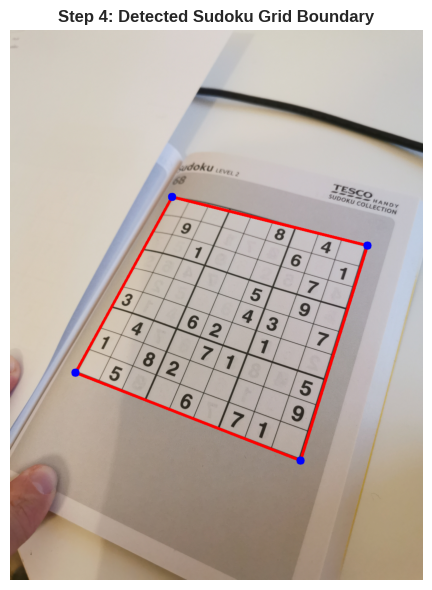

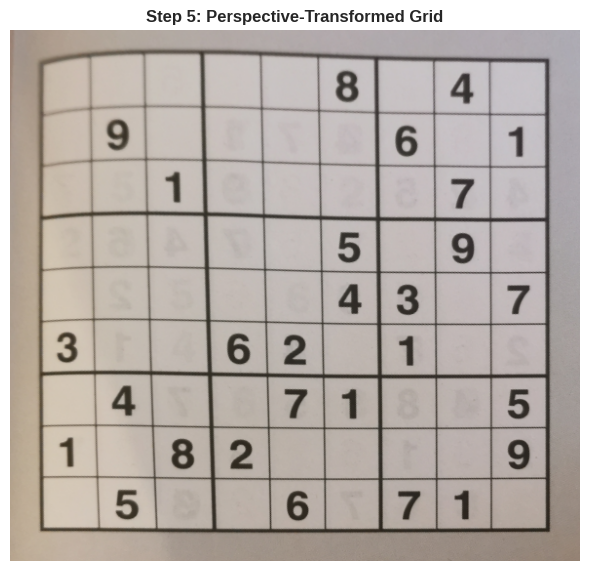

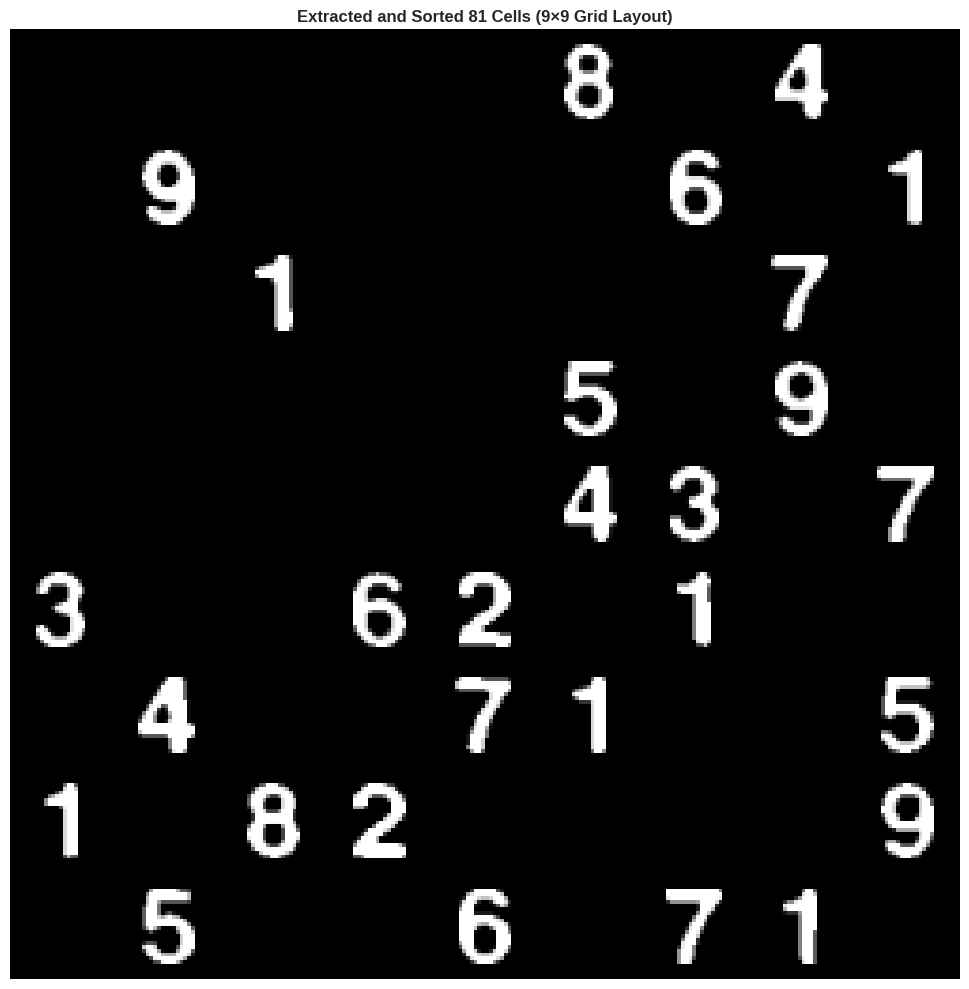

Predicted Grid:
[[0 0 0 0 0 8 0 4 0]
 [0 9 0 0 0 0 6 0 1]
 [0 0 1 0 0 0 0 3 0]
 [0 0 0 0 0 5 0 9 0]
 [0 0 0 0 0 4 3 0 3]
 [3 0 0 6 2 0 8 0 0]
 [0 4 0 0 3 1 0 0 5]
 [1 0 8 2 0 0 0 0 9]
 [0 5 0 0 6 0 7 1 0]]

Solved Grid:
0 0 0 | 0 0 8 | 0 4 0
0 9 0 | 0 0 0 | 6 0 1
0 0 1 | 0 0 0 | 0 3 0
- - - - - - - - - - - 
0 0 0 | 0 0 5 | 0 9 0
0 0 0 | 0 0 4 | 3 0 3
3 0 0 | 6 2 0 | 8 0 0
- - - - - - - - - - - 
0 4 0 | 0 3 1 | 0 0 5
1 0 8 | 2 0 0 | 0 0 9
0 5 0 | 0 6 0 | 7 1 0

Sudoku solved successfully!


In [76]:
if os.path.exists(sudoku_images_dir) and len(glob.glob(os.path.join(sudoku_images_dir, '*.jpg'))) > 0:
    # Use first available image
    img_path = glob.glob(os.path.join(sudoku_images_dir, '5.jpg'))[0]
    print(f"Processing: {os.path.basename(img_path)}")

    # Load and process image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = resize_and_maintain_aspect_ratio(input_image=img, new_width=1000)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    ax.set_title('Step 1: Original Sudoku Image', fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'sudoku_step1_original.png'), dpi=100, bbox_inches='tight')
    plt.show()

    thresh = apply_grayscale_blur_and_threshold(img, blocksize=41, c=8)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(thresh, cmap='gray')
    ax.set_title('Step 2: Adaptive Thresholding', fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'sudoku_step2_threshold.png'), dpi=100, bbox_inches='tight')
    plt.show()

    contours = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = imutils.grab_contours(contours)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    img_contours = img.copy()
    cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img_contours)
    ax.set_title('Step 3: All Detected Contours', fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'sudoku_step3_contours.png'), dpi=100, bbox_inches='tight')
    plt.show()

    img_grid_boundary = img.copy()
    for contour in contours:
        perimeter = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, 0.03 * perimeter, True)
        # Find the biggest 4-point contour
        if len(approx) == 4:
            cv2.drawContours(img_grid_boundary, [approx], -1, (255, 0, 0), 5)
            for point in approx:
                cv2.circle(img_grid_boundary, tuple(point[0]), 10, (0, 0, 255), -1)
            break
            
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img_grid_boundary)
    ax.set_title('Step 4: Detected Sudoku Grid Boundary', fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'sudoku_step4_boundary.png'), dpi=100, bbox_inches='tight')
    plt.show()

    try:
        # Extract cells (This runs the actual pipeline)
        cells, M, board_image = get_valid_cells_from_image(img)

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(board_image, cmap='gray')
        ax.set_title('Step 5: Perspective-Transformed Grid', fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'sudoku_step5_grid.png'), dpi=100, bbox_inches='tight')
        plt.show()

        fig = plot_cell_images_in_grid(cells)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'sudoku_step6_cells.png'), dpi=100, bbox_inches='tight')
        plt.show()

        # Get predictions
        grid_array = get_predicted_sudoku_grid_torch(model, cells, device)

        print("Predicted Grid:")
        print(grid_array)

        # Solve
        solver = SudokuSolver(board=copy.deepcopy(grid_array))
        solver.solve()

        print("\nSolved Grid:")
        solver.print_board()

        print("\nSudoku solved successfully!")

    except Exception as e:
        print(f"Error processing image: {e}")
else:
    print("\nNo sudoku images available for demonstration")
    print("You can add sudoku images to: data/sudoku_images/")